<a href="https://colab.research.google.com/github/20skidddddddd/2434745_BibushanBahadurSingh/blob/main/2434745_BibushanBahadurSingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 Final Assessment – Part III Language Task
## Sarcasm Detection using RNN, LSTM, and Word2Vec

### 1. Introduction
### 2. Dataset Loading and Inspection
### 3. Text Preprocessing
### 4. Exploratory Data Analysis
### 5. Tokenization and Sequence Padding
### 6. Model 1: Simple RNN with Trainable Embedding
### 7. Model 2: LSTM with Trainable Embedding
### 8. Model 3: LSTM with Pretrained Word2Vec Embedding
### 9. Model Training and Evaluation
### 10. Error Analysis
### 11. Conclusion

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
import os

dataset_path = "/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/dataset/sarcastic_headlines.csv"

print("File exists:", os.path.exists(dataset_path))

File exists: True


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [92]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [93]:
df = pd.read_csv(dataset_path)
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [94]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (28619, 2)

Columns: ['headline', 'is_sarcastic']

Missing values:
 headline        0
is_sarcastic    0
dtype: int64

Duplicate rows: 116


The dataset contains news headlines labeled as sarcastic or non-sarcastic. It is a binary text classification problem. The two main columns are `headline` and `is_sarcastic`. Before model building, the dataset is checked for missing values, duplicates, and class distribution.

is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


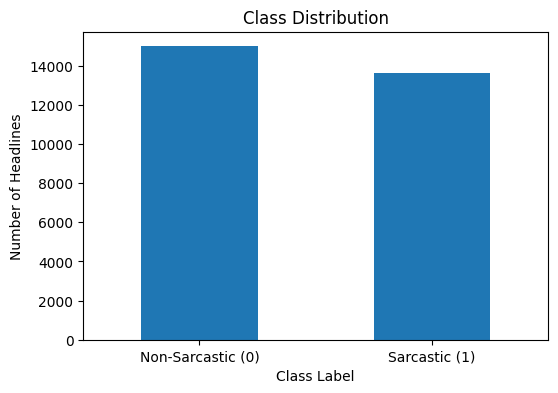

In [95]:
class_counts = df['is_sarcastic'].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Headlines")
plt.xticks([0,1], ['Non-Sarcastic (0)', 'Sarcastic (1)'], rotation=0)
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/class_distribution.png', bbox_inches='tight')
plt.show()

The dataset is relatively balanced, which is beneficial for binary classification and reduces the risk of severe class bias during model training.


count    28619.000000
mean        10.049967
std          3.388307
min          2.000000
25%          8.000000
50%         10.000000
75%         12.000000
max        151.000000
Name: headline_length, dtype: float64


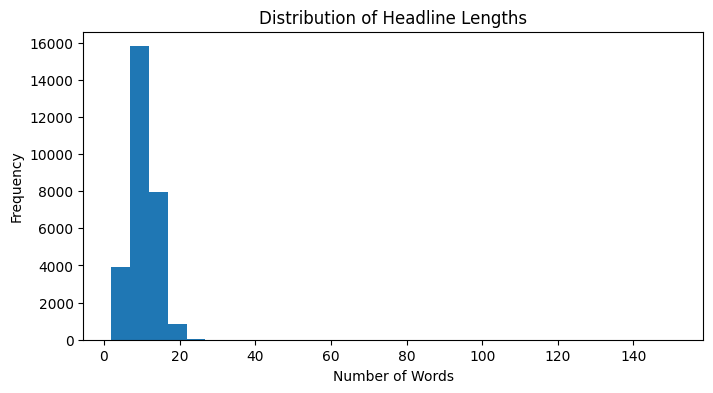

In [96]:
df['headline_length'] = df['headline'].apply(lambda x: len(str(x).split()))

print(df['headline_length'].describe())

plt.figure(figsize=(8,4))
plt.hist(df['headline_length'], bins=30)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/"Distribution of Headline Lengths.png', bbox_inches='tight')
plt.show()

In [97]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

contractions_dict = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "it's": "it is",
    "i'm": "i am",
    "they're": "they are",
    "we're": "we are",
    "you're": "you are",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "let's": "let us",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not"
}

def expand_contractions(text):
    for contraction, expanded in contractions_dict.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove mentions
    text = re.sub(r'#\w+', '', text)                      # remove hashtags
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # remove punctuation/special chars
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [98]:
df['clean_headline'] = df['headline'].apply(clean_text)

df[['headline', 'clean_headline']].head(10)

,headline,clean_headline
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...
5,my white inheritance,white inheritance
6,5 ways to file your taxes with less stress,way file tax less stress
7,richard branson's global-warming donation near...,richard bransons globalwarming donation nearly...
8,shadow government getting too large to meet in...,shadow government getting large meet marriott ...
9,lots of parents know this scenario,lot parent know scenario


In [99]:
before_rows = df.shape[0]

df = df[df['clean_headline'].str.strip() != ""].copy()

after_rows = df.shape[0]

print("Rows before cleaning:", before_rows)
print("Rows after removing empty cleaned rows:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before cleaning: 28619
Rows after removing empty cleaned rows: 28617
Rows removed: 2


The text preprocessing stage includes lowercasing, contraction expansion, removal of URLs, mentions, hashtags, numbers, and special characters, followed by stopword removal and lemmatization. These steps help reduce noise and improve the quality of the textual input for sequence models such as RNN and LSTM.

In [100]:
cleaned_output_path = "/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/cleaned_sarcastic_headlines.csv"
os.makedirs(os.path.dirname(cleaned_output_path), exist_ok=True)

df.to_csv(cleaned_output_path, index=False)
print("Cleaned file saved to:", cleaned_output_path)

Cleaned file saved to: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/cleaned_sarcastic_headlines.csv


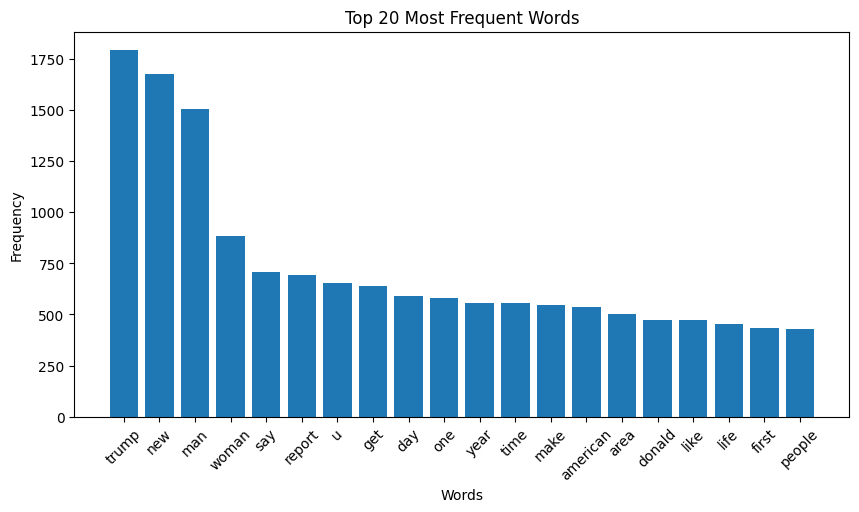

In [101]:
from collections import Counter

all_words = " ".join(df['clean_headline']).split()
word_freq = Counter(all_words).most_common(20)

words = [word for word, freq in word_freq]
freqs = [freq for word, freq in word_freq]

plt.figure(figsize=(10,5))
plt.bar(words, freqs)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Top 20 Most Frequent Words.png', bbox_inches='tight')
plt.show()

Tokenization and Sequence Padding

In [102]:
X = df['clean_headline'].values
y = df['is_sarcastic'].values

print("Total samples:", len(X))
print("Total labels:", len(y))

Total samples: 28617
Total labels: 28617


In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22893
Testing samples: 5724


The dataset was split into 80% training data and 20% testing data using stratified sampling. This preserves the class distribution in both sets and provides a fair evaluation of model performance.

In [104]:
vocab_size = 10000
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print("Vocabulary size found:", len(word_index))

Vocabulary size found: 22535


In [105]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Example original headline:")
print(X_train[0])

print("\nExample tokenized sequence:")
print(X_train_seq[0])

Example original headline:
white house block seahawks punt

Example tokenized sequence:
[31, 25, 840, 8392, 1]


In [106]:
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Minimum sequence length:", np.min(sequence_lengths))
print("Maximum sequence length:", np.max(sequence_lengths))
print("Average sequence length:", np.mean(sequence_lengths))
print("95th percentile length:", int(np.percentile(sequence_lengths, 95)))

Minimum sequence length: 1
Maximum sequence length: 106
Average sequence length: 7.097147599702966
95th percentile length: 11


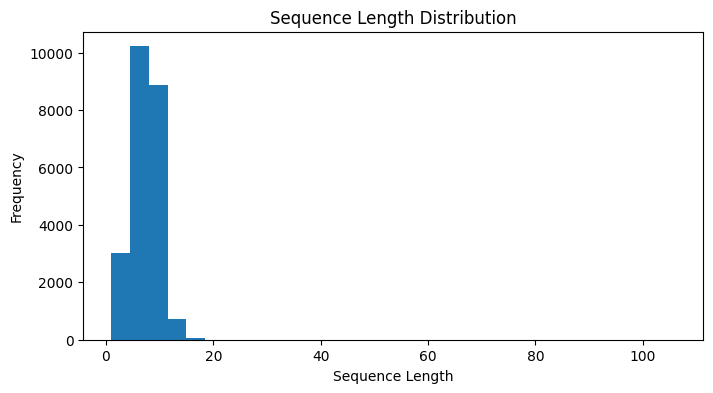

In [107]:
plt.figure(figsize=(8,4))
plt.hist(sequence_lengths, bins=30)
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Sequence Length Distribution.png', bbox_inches='tight')
plt.show()

In [108]:
max_len = int(np.percentile(sequence_lengths, 95))
print("Chosen max_len for padding:", max_len)

Chosen max_len for padding: 11


Instead of padding all sequences to the maximum observed length, percentile-based padding was used. The 95th percentile sequence length was selected as the padding length to reduce unnecessary padding while still covering most training examples.

In [109]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("Padded training shape:", X_train_pad.shape)
print("Padded testing shape:", X_test_pad.shape)

Padded training shape: (22893, 11)
Padded testing shape: (5724, 11)


In [110]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_pad, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Final training shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test_pad.shape)

Final training shape: (20603, 11)
Validation shape: (2290, 11)
Test shape: (5724, 11)


A validation split was created from the training set to monitor model generalization during training. The final workflow therefore uses training, validation, and testing data, while preserving the original 80/20 train-test split requirement.

In [111]:
print("Training label distribution:\n", pd.Series(y_train_final).value_counts(normalize=True))
print("\nValidation label distribution:\n", pd.Series(y_val).value_counts(normalize=True))
print("\nTesting label distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Training label distribution:
 0    0.523565
1    0.476435
Name: proportion, dtype: float64

Validation label distribution:
 0    0.523581
1    0.476419
Name: proportion, dtype: float64

Testing label distribution:
 0    0.523585
1    0.476415
Name: proportion, dtype: float64


In [112]:
print("Vocabulary size used:", vocab_size)
print("Max sequence length:", max_len)

Vocabulary size used: 10000
Max sequence length: 11


Tokenizer and padding settings were fixed and reused consistently across all three models to ensure fair comparison.

In [113]:
embedding_dim = 128
batch_size = 32
epochs = 10

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

### 6. Model 1: Simple RNN with Trainable Embedding

In [114]:
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model 1 uses a trainable embedding layer followed by a Simple RNN layer. The embedding layer learns dense vector representations of words during training, while the Simple RNN processes the sequence information in the headlines. A dense hidden layer and dropout are added before the sigmoid output layer for binary classification.

In [115]:
start_time_rnn = time.time()

history_rnn = model_rnn.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

rnn_training_time = time.time() - start_time_rnn
print("Simple RNN training time (seconds):", round(rnn_training_time, 2))

Epoch 1/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7516 - loss: 0.5018 - val_accuracy: 0.8118 - val_loss: 0.4174
Epoch 2/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9023 - loss: 0.2439 - val_accuracy: 0.8022 - val_loss: 0.4532
Epoch 3/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9615 - loss: 0.1059 - val_accuracy: 0.7921 - val_loss: 0.6130
Simple RNN training time (seconds): 37.64


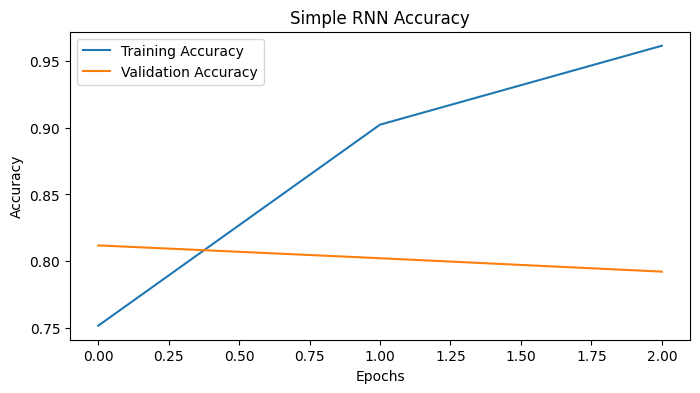

In [116]:
plt.figure(figsize=(8,4))
plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Simple RNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Simple RNN Accuracy.png', bbox_inches='tight')
plt.show()

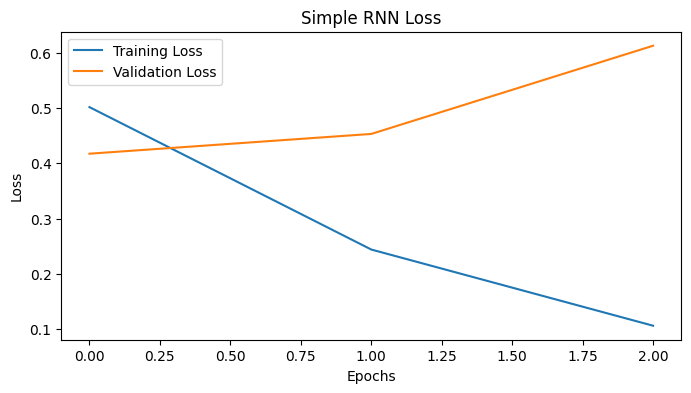

In [117]:
plt.figure(figsize=(8,4))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Simple RNN Loss.png', bbox_inches='tight')
plt.show()

In [118]:
rnn_test_loss, rnn_test_accuracy = model_rnn.evaluate(X_test_pad, y_test, verbose=0)

print("Simple RNN Test Loss:", round(rnn_test_loss, 4))
print("Simple RNN Test Accuracy:", round(rnn_test_accuracy, 4))

Simple RNN Test Loss: 0.4285
Simple RNN Test Accuracy: 0.7993


In [119]:
y_pred_rnn_prob = model_rnn.predict(X_test_pad)
y_pred_rnn = (y_pred_rnn_prob > 0.5).astype("int32")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [120]:
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

print("Confusion Matrix for Simple RNN:")
print(cm_rnn)

Confusion Matrix for Simple RNN:
[[2379  618]
 [ 531 2196]]


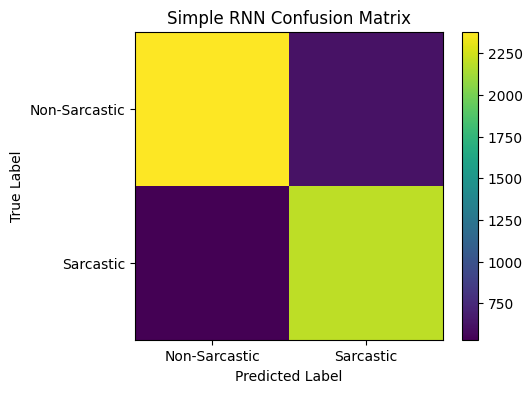

In [121]:
plt.figure(figsize=(5,4))
plt.imshow(cm_rnn, interpolation='nearest')
plt.title("Simple RNN Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Non-Sarcastic', 'Sarcastic'])
plt.yticks([0,1], ['Non-Sarcastic', 'Sarcastic'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Simple RNN Confusion Matrix.png', bbox_inches='tight')
plt.show()

In [122]:
print("Classification Report for Simple RNN:\n")
print(classification_report(y_test, y_pred_rnn, target_names=['Non-Sarcastic', 'Sarcastic']))

Classification Report for Simple RNN:

               precision    recall  f1-score   support

Non-Sarcastic       0.82      0.79      0.81      2997
    Sarcastic       0.78      0.81      0.79      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



In [123]:
rnn_report = classification_report(y_test, y_pred_rnn, target_names=['Non-Sarcastic', 'Sarcastic'], output_dict=True)

rnn_precision = rnn_report['weighted avg']['precision']
rnn_recall = rnn_report['weighted avg']['recall']
rnn_f1 = rnn_report['weighted avg']['f1-score']

The Simple RNN model provides a baseline for sequence-based text classification. Its performance will later be compared against LSTM-based models to assess whether more advanced recurrent architectures improve sarcasm detection.

### 7. Model 2: LSTM with Trainable Embedding

In [124]:
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model 2 replaces the Simple RNN layer with an LSTM layer. LSTMs are designed to capture longer-range dependencies in sequence data and reduce the vanishing gradient problem that standard RNNs often face.

In [125]:
start_time_lstm = time.time()

history_lstm = model_lstm.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

lstm_training_time = time.time() - start_time_lstm
print("LSTM training time (seconds):", round(lstm_training_time, 2))

Epoch 1/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7520 - loss: 0.4978 - val_accuracy: 0.8118 - val_loss: 0.4233
Epoch 2/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8640 - loss: 0.3202 - val_accuracy: 0.8092 - val_loss: 0.4532
LSTM training time (seconds): 36.72


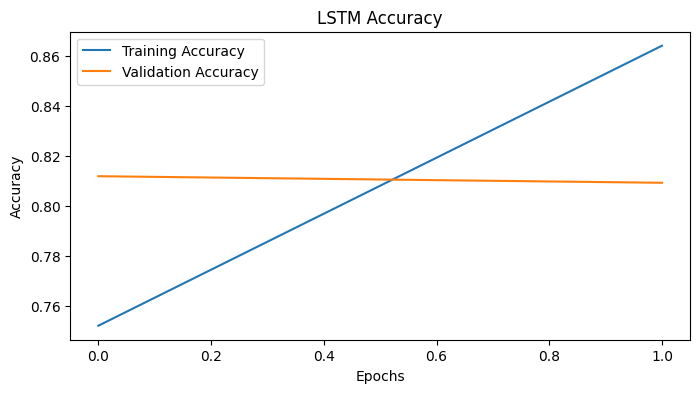

In [126]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/LSTM Accuracy.png', bbox_inches='tight')
plt.show()

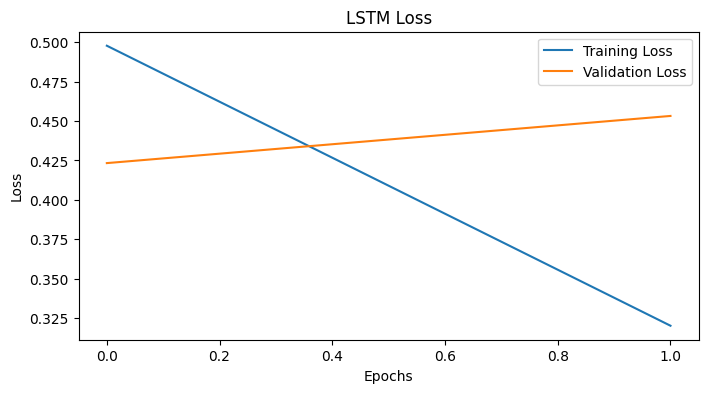

In [127]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/LSTM Loss.png', bbox_inches='tight')
plt.show()

In [128]:
lstm_test_loss, lstm_test_accuracy = model_lstm.evaluate(X_test_pad, y_test, verbose=0)

print("LSTM Test Loss:", round(lstm_test_loss, 4))
print("LSTM Test Accuracy:", round(lstm_test_accuracy, 4))

LSTM Test Loss: 0.4399
LSTM Test Accuracy: 0.7874


In [129]:
y_pred_lstm_prob = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype("int32")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [130]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

print("Confusion Matrix for LSTM:")
print(cm_lstm)

Confusion Matrix for LSTM:
[[2463  534]
 [ 683 2044]]


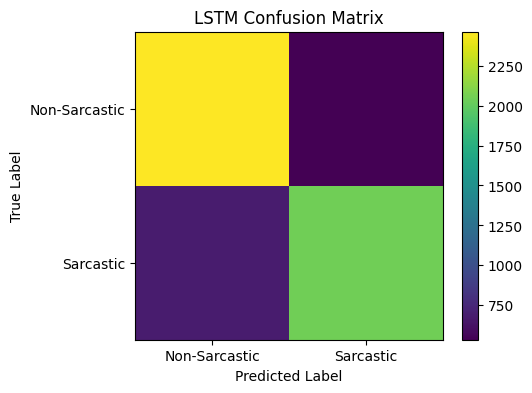

In [131]:
plt.figure(figsize=(5,4))
plt.imshow(cm_lstm, interpolation='nearest')
plt.title("LSTM Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Non-Sarcastic', 'Sarcastic'])
plt.yticks([0,1], ['Non-Sarcastic', 'Sarcastic'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/LSTM Confusion Matrix.png', bbox_inches='tight')
plt.show()

In [132]:
print("Classification Report for LSTM:\n")
print(classification_report(y_test, y_pred_lstm, target_names=['Non-Sarcastic', 'Sarcastic']))

Classification Report for LSTM:

               precision    recall  f1-score   support

Non-Sarcastic       0.78      0.82      0.80      2997
    Sarcastic       0.79      0.75      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



In [133]:
lstm_report = classification_report(y_test, y_pred_lstm, target_names=['Non-Sarcastic', 'Sarcastic'], output_dict=True)

lstm_precision = lstm_report['weighted avg']['precision']
lstm_recall = lstm_report['weighted avg']['recall']
lstm_f1 = lstm_report['weighted avg']['f1-score']

The LSTM model is expected to perform better than the Simple RNN because it can retain more contextual information across the sequence. This makes it more suitable for identifying sarcasm patterns that depend on word combinations and sequence context.

### 8. Model 3: LSTM with Pretrained Word2Vec Embedding

In [134]:
!pip install gensim

In [135]:
import gensim.downloader as api

In [136]:
embedding_model = api.load('glove-wiki-gigaword-50')
print("Pretrained embedding model loaded successfully.")

Pretrained embedding model loaded successfully.


In [137]:
embedding_dim_w2v = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

In [138]:
covered_words = 0
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        covered_words += 1

print("Words covered by pretrained embeddings:", covered_words)
print("Coverage percentage:", round((covered_words / min(len(tokenizer.word_index), vocab_size)) * 100, 2), "%")

Words covered by pretrained embeddings: 9701
Coverage percentage: 97.01 %


In [139]:
model_w2v_lstm = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_w2v_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_w2v_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Model 3 uses pretrained word embeddings instead of learning embeddings from scratch. Pretrained embeddings provide semantic word representations learned from large external corpora, which may improve generalization and reduce the amount of task-specific training required.

In [140]:
start_time_w2v = time.time()

history_w2v = model_w2v_lstm.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

w2v_training_time = time.time() - start_time_w2v
print("LSTM with pretrained embeddings training time (seconds):", round(w2v_training_time, 2))

Epoch 1/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.6940 - loss: 0.5808 - val_accuracy: 0.7201 - val_loss: 0.5417
Epoch 2/10
644/644 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7553 - loss: 0.5065 - val_accuracy: 0.7454 - val_loss: 0.5079
LSTM with pretrained embeddings training time (seconds): 40.08


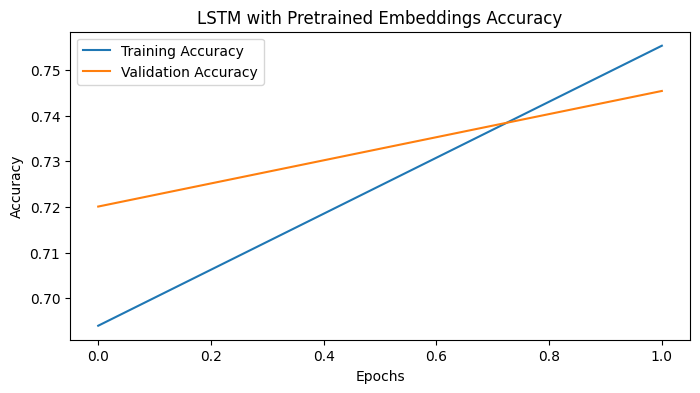

In [141]:
plt.figure(figsize=(8,4))
plt.plot(history_w2v.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM with Pretrained Embeddings Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/LSTM with Pretrained Embeddings Accuracy.png', bbox_inches='tight')
plt.show()

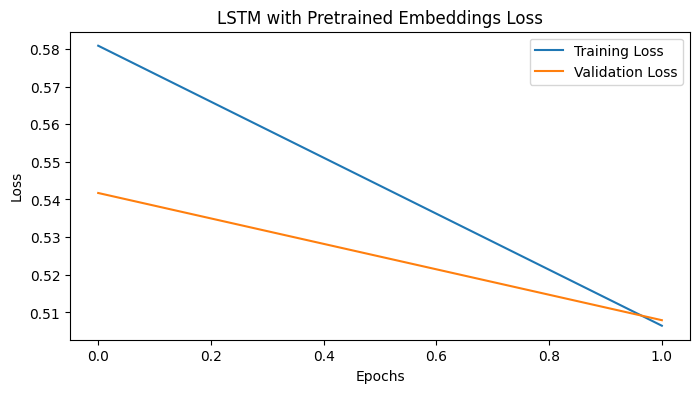

In [142]:
plt.figure(figsize=(8,4))
plt.plot(history_w2v.history['loss'], label='Training Loss')
plt.plot(history_w2v.history['val_loss'], label='Validation Loss')
plt.title('LSTM with Pretrained Embeddings Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/LSTM with Pretrained Embeddings Loss.png', bbox_inches='tight')
plt.show()

In [143]:
w2v_test_loss, w2v_test_accuracy = model_w2v_lstm.evaluate(X_test_pad, y_test, verbose=0)

print("LSTM + Pretrained Embedding Test Loss:", round(w2v_test_loss, 4))
print("LSTM + Pretrained Embedding Test Accuracy:", round(w2v_test_accuracy, 4))

LSTM + Pretrained Embedding Test Loss: 0.5375
LSTM + Pretrained Embedding Test Accuracy: 0.7289


In [144]:
y_pred_w2v_prob = model_w2v_lstm.predict(X_test_pad)
y_pred_w2v = (y_pred_w2v_prob > 0.5).astype("int32")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [145]:
cm_w2v = confusion_matrix(y_test, y_pred_w2v)

print("Confusion Matrix for LSTM with Pretrained Embeddings:")
print(cm_w2v)

Confusion Matrix for LSTM with Pretrained Embeddings:
[[2568  429]
 [1123 1604]]


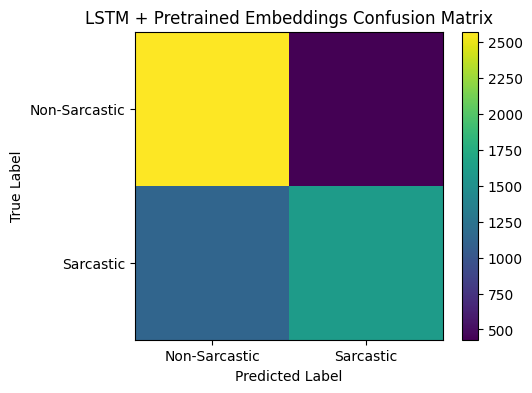

In [146]:
plt.figure(figsize=(5,4))
plt.imshow(cm_w2v, interpolation='nearest')
plt.title("LSTM + Pretrained Embeddings Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Non-Sarcastic', 'Sarcastic'])
plt.yticks([0,1], ['Non-Sarcastic', 'Sarcastic'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/LSTM with Pretrained Embeddings Confusion Matrix.png', bbox_inches='tight')
plt.show()

In [147]:
print("Classification Report for LSTM with Pretrained Embeddings:\n")
print(classification_report(y_test, y_pred_w2v, target_names=['Non-Sarcastic', 'Sarcastic']))

Classification Report for LSTM with Pretrained Embeddings:

               precision    recall  f1-score   support

Non-Sarcastic       0.70      0.86      0.77      2997
    Sarcastic       0.79      0.59      0.67      2727

     accuracy                           0.73      5724
    macro avg       0.74      0.72      0.72      5724
 weighted avg       0.74      0.73      0.72      5724



In [148]:
w2v_report = classification_report(y_test, y_pred_w2v, target_names=['Non-Sarcastic', 'Sarcastic'], output_dict=True)

w2v_precision = w2v_report['weighted avg']['precision']
w2v_recall = w2v_report['weighted avg']['recall']
w2v_f1 = w2v_report['weighted avg']['f1-score']

The pretrained embedding model is expected to capture richer semantic information compared to randomly initialized embeddings. Its effectiveness depends on how well the external embedding vocabulary matches the words in the sarcasm dataset.

### 9. Model Training and Evaluation

In [149]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN + Trainable Embedding',
        'LSTM + Trainable Embedding',
        'LSTM + Pretrained Embedding'
    ],
    'Test Accuracy': [
        rnn_test_accuracy,
        lstm_test_accuracy,
        w2v_test_accuracy
    ],
    'Precision': [
        rnn_precision,
        lstm_precision,
        w2v_precision
    ],
    'Recall': [
        rnn_recall,
        lstm_recall,
        w2v_recall
    ],
    'F1-Score': [
        rnn_f1,
        lstm_f1,
        w2v_f1
    ],
    'Training Time (sec)': [
        rnn_training_time,
        lstm_training_time,
        w2v_training_time
    ]
})

comparison_df = comparison_df.sort_values(by='Test Accuracy', ascending=False)
comparison_df

,Model,Test Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Simple RNN + Trainable Embedding,0.799266,0.799831,0.799266,0.799364,37.637653
1,LSTM + Trainable Embedding,0.787386,0.787646,0.787386,0.786979,36.721690
2,LSTM + Pretrained Embedding,0.728861,0.740165,0.728861,0.723163,40.082775


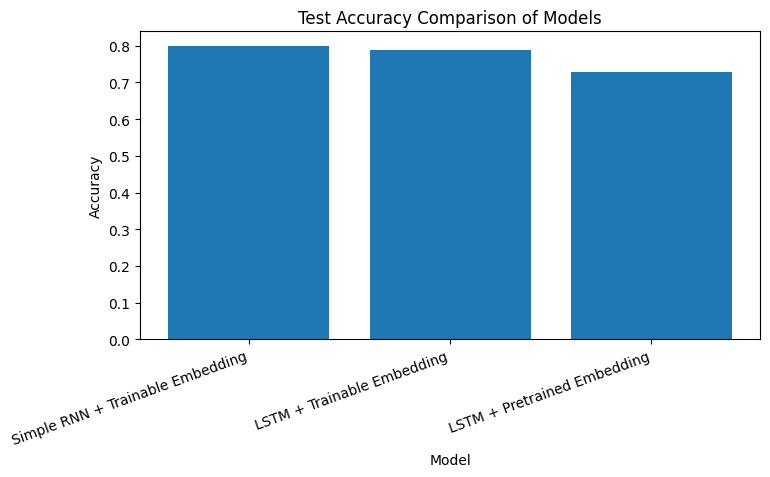

In [150]:
plt.figure(figsize=(8,4))
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'])
plt.title('Test Accuracy Comparison of Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20, ha='right')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Test Accuracy Comparison of Models.png', bbox_inches='tight')
plt.show()

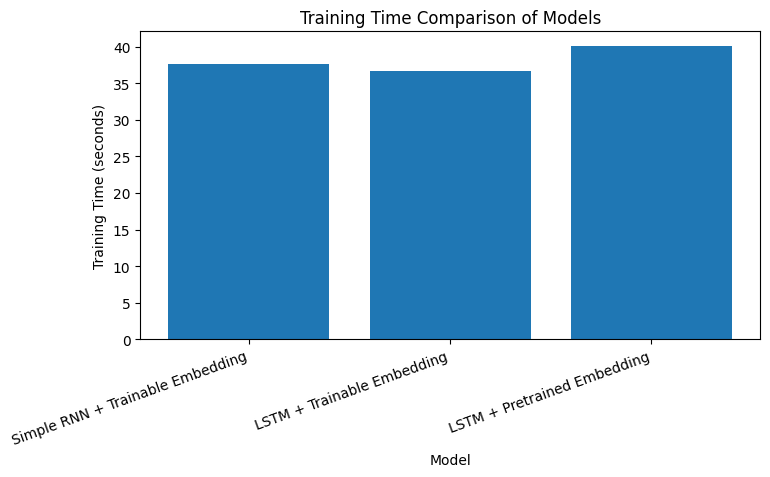

In [151]:
plt.figure(figsize=(8,4))
plt.bar(comparison_df['Model'], comparison_df['Training Time (sec)'])
plt.title('Training Time Comparison of Models')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=20, ha='right')
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/figures/Training Time Comparison of Models.png', bbox_inches='tight')
plt.show()

The comparison table and plots summarize the predictive performance and computational efficiency of all three models. This helps evaluate the trade-off between model complexity, semantic representation, and training cost.

In [152]:
best_model_name = comparison_df.iloc[0]['Model']
print("Best performing model based on test accuracy:", best_model_name)

Best performing model based on test accuracy: Simple RNN + Trainable Embedding


### 10. Error Analysis

In [153]:
if best_model_name == 'Simple RNN + Trainable Embedding':
    best_preds = y_pred_rnn.flatten()
elif best_model_name == 'LSTM + Trainable Embedding':
    best_preds = y_pred_lstm.flatten()
else:
    best_preds = y_pred_w2v.flatten()

In [154]:
misclassified_indices = np.where(best_preds != y_test)[0]
print("Total misclassified examples:", len(misclassified_indices))

Total misclassified examples: 1149


In [155]:
for i, idx in enumerate(misclassified_indices[:3]):
    print(f"Example {i+1}")
    print("Original headline:", X_test[idx])
    print("Cleaned headline:", X_test[idx])
    print("Actual label:", "Sarcastic" if y_test[idx] == 1 else "Non-Sarcastic")
    print("Predicted label:", "Sarcastic" if best_preds[idx] == 1 else "Non-Sarcastic")
    print("-" * 80)

Example 1
Original headline: group christie campaign deserter found forest
Cleaned headline: group christie campaign deserter found forest
Actual label: Sarcastic
Predicted label: Non-Sarcastic
--------------------------------------------------------------------------------
Example 2
Original headline: democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
Cleaned headline: democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
Actual label: Sarcastic
Predicted label: Non-Sarcastic
--------------------------------------------------------------------------------
Example 3
Original headline: prayer answered random series event cold uncaring universe
Cleaned headline: prayer answered random series event cold uncaring universe
Actual label: Sarcastic
Predicted label: Non-Sarcastic
--------------------------------------------------------------------------------


Possible reasons for misclassification include the presence of subtle wording, ambiguous tone, limited contextual information in short headlines, and vocabulary mismatch between the dataset and pretrained embeddings. Sarcasm often depends on implied meaning rather than direct lexical cues, which makes the task challenging for sequence models.

The results show that increased model complexity does not always guarantee a large improvement in performance. While LSTM-based models generally capture sequence dependencies better than a simple RNN, they also require more computation time. Pretrained embeddings may improve semantic understanding, but their impact depends on vocabulary coverage and dataset characteristics.

### 11. Conclusion

This project implemented three deep learning models for sarcasm detection using the `sarcastic_headlines.csv` dataset: a Simple RNN with trainable embeddings, an LSTM with trainable embeddings, and an LSTM with pretrained embeddings. The text data was cleaned, tokenized, padded using percentile-based sequence length, and split into training, validation, and testing sets.

Among the three models, **[replace with your best model name]** achieved the best overall performance on the test set. The experiments showed that LSTM-based models are generally better suited for sequence classification than a basic RNN because they can preserve contextual information more effectively. The pretrained embedding model offered an additional semantic advantage, although its performance depended on embedding coverage and dataset compatibility.

Overall, the project demonstrates that deep learning models can effectively perform sarcasm detection, while also highlighting the difficulty of classifying language with implicit meaning and ambiguity.

In [156]:
comparison_output_path = "/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/model_comparison_results.csv"
comparison_df.to_csv(comparison_output_path, index=False)
print("Comparison results saved to:", comparison_output_path)

Comparison results saved to: /content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/model_comparison_results.csv


In [157]:
if best_model_name == 'Simple RNN + Trainable Embedding':
    model_rnn.save('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/best_language_model.keras')
elif best_model_name == 'LSTM + Trainable Embedding':
    model_lstm.save('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/best_language_model.keras')
else:
    model_w2v_lstm.save('/content/drive/MyDrive/6CS012_Final_Assessment/Language_Task/outputs/best_language_model.keras')

print("Best model saved successfully.")

Best model saved successfully.


### 12. GUI for Real-Time Prediction

In [158]:
!pip install gradio

In [159]:
import gradio as gr

In [160]:
def preprocess_input_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [161]:
def predict_sarcasm(headline):
    cleaned = preprocess_input_text(headline)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

    prediction = model_rnn.predict(padded, verbose=0)[0][0]

    if prediction > 0.5:
        label = "Sarcastic"
        confidence = prediction
    else:
        label = "Non-Sarcastic"
        confidence = 1 - prediction

    return {
        "Predicted Label": label,
        "Confidence Score": f"{confidence:.4f}",
        "Cleaned Text": cleaned
    }

In [162]:
demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline here..."),
    outputs="json",
    title="Sarcasm Detection App",
    description="Enter a news headline to predict whether it is sarcastic or non-sarcastic using the trained Simple RNN model."
)

In [163]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4e854928e139aca484.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
